## RESULTS Analysis Notebook

This notebook explores SWOT flood-depth descriptors and their relationship with VIIRS flood metrics in the Health Facilities provided by WHO across South Sudan.

## Overview
- Load and prepare SWOT descriptors.
- Filter outliers and compute anomaly-based metrics.
- Visualize oscillation ranges, distributions, and maps.
- Analyze correlations between SWOT variables and VIIRS flood fraction.

## Main output:
- Prquet file with time flood descriptors time series at HF level.

## Data source
The results in this analysis are based on the following dataset:

*GMV Innovating Solutions (Spain). (2026). SWOT-based flood descriptors - South Sudan, 2023-2025 (Version v1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.20622861*

***

__author__ = "Miguel González Jiménez, migj" <br>
__maintainer__ = "Miguel González Jiménez, migj"<br>
__email__ = "mgonzalez.j@gmv.com"

***

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.notebook import tqdm

import SWOT as swot

import warnings
warnings.filterwarnings('ignore')

In [ ]:
path_Model = Path(r"path_to_folder_containing_geojson_output_files")
# The one used corresponds with this Zenodo dataset: https://doi.org/10.5281/zenodo.20622861

Model = swot.Results(path_Model)

Model.gdf = Model.gdf[Model.gdf.IsFlooded] # Deleting non-flooded registers
Model.del_outliers(z=2.5, field='Median').to_anomalies(how='min')

  0%|          | 0/898 [00:00<?, ?it/s]

With outliers: 11264 entries
Without outliers: 11116 entries


### Plot outliers

Text(0.5, 1.0, 'Healt Facility: kongor phcc, ID 201')

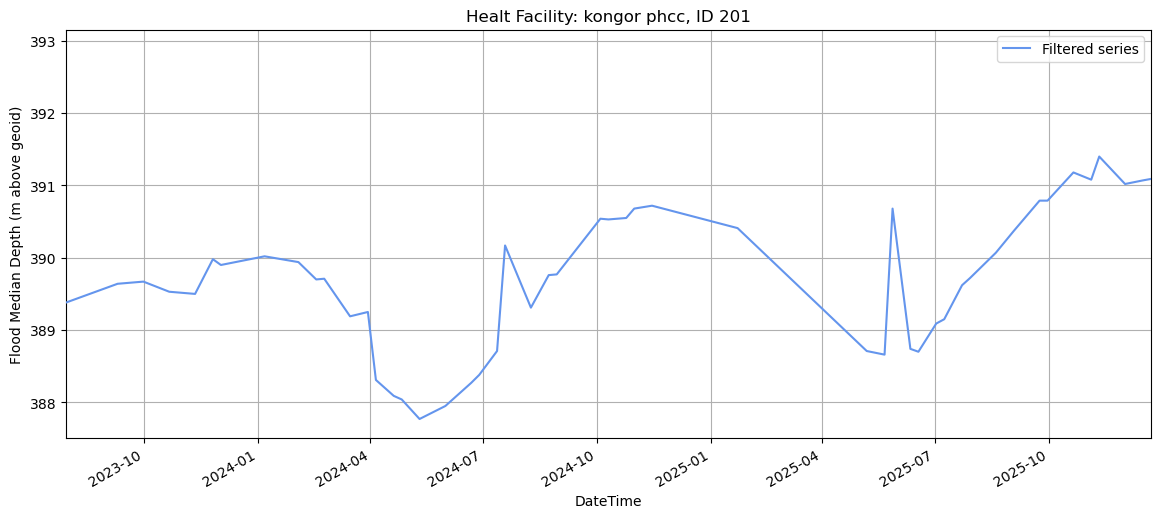

In [3]:
index = Model.getSerie('201')['Median'].index

ax = Model.plotOutlier('262', field='Median', grid=True)
ax.set_xlim(index.min(), index.max())
ax.set_ylabel("Flood Median Depth (m above geoid)")

name, _id = Model.getSerie('201')[['hf_id', 'ID']].iloc[0].values
ax.set_title(f"Healt Facility: {name}, ID {_id}")

### Box plot

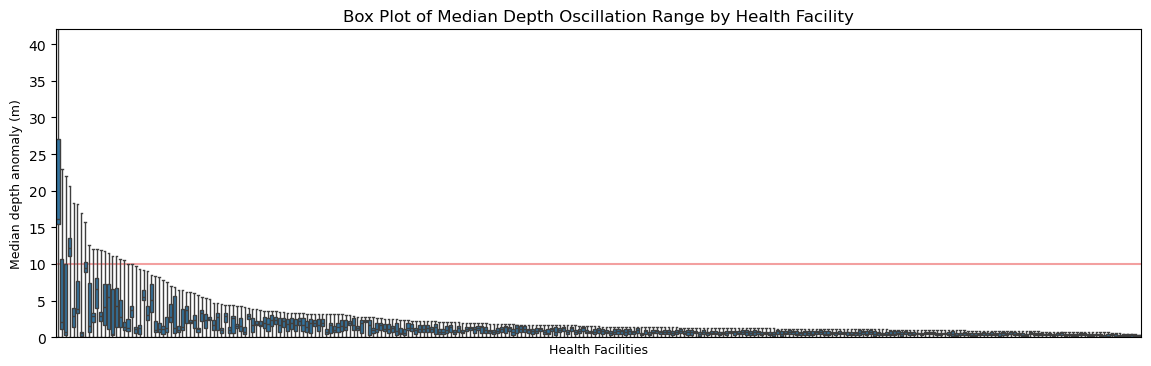

In [8]:
_, ax = plt.subplots(figsize=(14,4))
Model.boxPlot('Median_anomaly', ax=ax)
ax.axhline(10, color='lightcoral', alpha=0.75, zorder=0)

ax.set_ylim(0,42)
ax.set_ylabel('Median depth anomaly (m)', fontsize=9)
ax.set_xlabel('Health Facilities', fontsize=9)
ax.set_title('Box Plot of Median Depth Oscillation Range by Health Facility', fontsize=12)
ax.tick_params(axis='x', labelbottom=False, bottom=False)

### Saving time series plots
Of FloodFraction and MedianDepth_anomaly for all HF along with VIIRS time-series

In [ ]:
outdir = Path(r"path_to_output_folder1")
for i in tqdm(Model.ids, total=len(Model.ids)):
    Model.plotWithViirs(id=i)[0][0].figure.savefig(outdir/i)
    plt.close()

outdir = Path(r"path_to_output_folder2")
for i in tqdm(Model.ids, total=len(Model.ids)):
    Model.plotWithViirs(id=i, field='Median_anomaly')[0][0].figure.savefig(outdir/i)
    plt.close()

### Oscillation Range plot
According to Median depth values

In [9]:
Model.get_Oscil('Median_anomaly').quantile(0.95)

11.17299999999999

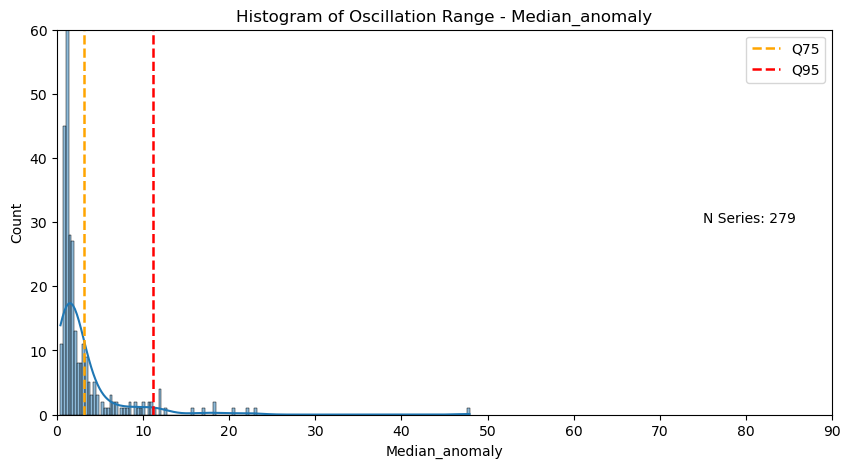

In [ ]:
Model.oscilHist('Median_anomaly')

### Getting map of Median Depth anomaly of HF

In [ ]:
oscilMedian = pd.DataFrame(Model.get_Oscil('Median_anomaly')).join(Model.gdf.groupby('ID').first()[['longitude','latitude']])
oscilMedian_gdf = gpd.GeoDataFrame(oscilMedian,
                                   geometry=gpd.points_from_xy(x=oscilMedian['longitude'], y=oscilMedian['latitude']))
oscilMedian_gdf.to_file(f"OscilMedian.geojson",
                        driver='GeoJSON')

### Map of Oscillation

<Axes: >

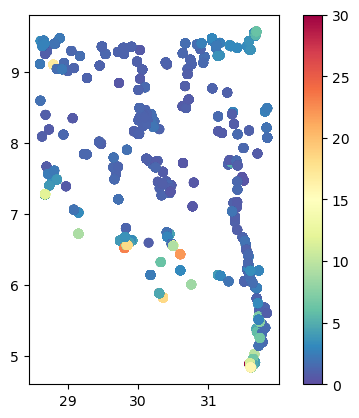

In [ ]:
Model.oscilMap('Median', vmin=0, vmax=30)

### Taking ids of fluctuations greater than 10m

In [ ]:
gdf_oscil = Model.get_Oscil('Median_anomaly')

ids_above = gdf_oscil[gdf_oscil>10].index.tolist()

print(f"There are {len(ids_above)} series with range values (MeanDepth) above 10m. This is {round(100*len(ids_above)/len(Model.ids), 2)} % of total series.")

There are 20 series with range values (MeanDepth) above 10m. This is 7.17 % of total series.


In [ ]:
for i in Model.ids:
    if not i in ids_above:
        Model.plot(i).figure.savefig(fr"path_to_output_folder/Plot-Median_lowerthan10/{i}.png")
        plt.close()

### Removing HF above 10 meters from gdf and store it (DEFINITIVE)

In [ ]:
mask = ~Model.gdf['ID'].isin(ids_above)
gdf_FINAL = Model.gdf[mask]

In [ ]:
# Quick check:
print(f"Removed ({len(ids_above)}) HFs is equal than total ({len(Model.ids)}) less above 10m ({Model.gdf[mask]['ID'].unique().shape[0]})")

Removed (20) HFs is equal than total (279) less above 10m (259)


In [ ]:
final_columns = ['hf_id', 'longitude', 'latitude', 'hf_payam', 'ID', 'path', 'IsOutlier',
                 'FloodFraction', 'Mean_anomaly', 'Median_anomaly', 'Max_anomaly', 'Distance',
                 '_FloodFrac_Uncert', 'Mean_Anomaly_Uncert', 'Median_Anomaly_Uncert', 'Max_Anomaly_Uncert', '_Distance_Uncert',
                 'buffer_pixels', 'zona_nombre', 'patch_size', 'index_right']

gdf_FINAL[final_columns]

,hf_id,longitude,latitude,hf_payam,ID,path,IsOutlier,FloodFraction,Mean_anomaly,Median_anomaly,...,Distance,_FloodFrac_Uncert,Mean_Anomaly_Uncert,Median_Anomaly_Uncert,Max_Anomaly_Uncert,_Distance_Uncert,buffer_pixels,zona_nombre,patch_size,index_right
DateTime,,,,,,,,,,,,,,,,,,,,,
2024-11-14 12:40:16.615000+00:00,assossa phcu,31.667500,9.515500,SS070705,102,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.145405,2.73,2.75,...,2597.172273,0.007,0.007,0.010,0.134,401.271,60,CHRONIC,5400,0
2024-11-14 12:40:16.615000+00:00,bam phcu,31.659230,9.503360,SS070705,103,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.283265,2.73,2.75,...,2918.800750,0.008,0.005,0.008,0.033,605.197,60,CHRONIC,5400,0
2024-11-14 12:40:16.615000+00:00,diel phcu,31.302780,9.374180,SS030402,041,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.464335,2.37,2.69,...,1743.862314,0.009,0.006,0.009,0.020,676.571,60,UNSTABLE,5400,0
2024-11-14 12:40:16.615000+00:00,imc malakal poc clinic 1,31.678145,9.565245,SS070701,250,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.104938,3.19,2.42,...,991.510594,0.006,0.035,0.019,0.201,226.568,60,CHRONIC,5400,0
2024-11-14 12:40:16.615000+00:00,khorfulus phcc,31.579980,9.314760,SS030402,042,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.013117,2.89,2.94,...,1698.594965,0.003,0.055,0.043,0.258,249.694,40,UNSTABLE,3600,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-04 23:09:09.660000+00:00,pagil phcc,31.266110,8.708050,SS030205,022,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.500772,0.40,0.44,...,2166.545865,0.014,0.013,0.025,0.031,561.629,40,UNSTABLE,3600,0
2023-11-04 23:09:09.660000+00:00,pathai phcu,31.834960,8.072230,SS031102,207,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.410494,0.93,1.12,...,2727.025084,0.009,0.046,1.278,0.077,674.520,60,CHRONIC,5400,0
2023-11-04 23:09:09.660000+00:00,riang phcu,31.833494,8.488860,SS030702,130,/mnt/staas/CLICHE/00_DATA/SWOT/SWOT_frames_Ver...,False,0.054870,1.06,1.04,...,2626.525155,0.004,0.047,0.112,0.068,254.522,60,CHRONIC,5400,0


In [ ]:
gdf_FINAL.to_parquet("..data/SWOT_flood_descriptors_2023-2025_non-SAFE_SouthSudan.parquet")

## Correlation Analysis with VIIRS data

In [ ]:
corr_Perc = [Model.plotWithViirs(id=i, plot=False) for i in tqdm(Model.ids)]
corr_Mean = [Model.plotWithViirs(id=i, field='Mean_anomaly', plot=False) for i in tqdm(Model.ids)]
corr_Median = [Model.plotWithViirs(id=i, field='Median_anomaly', plot=False) for i in tqdm(Model.ids)]
corr_Max = [Model.plotWithViirs(id=i, field='Max_anomaly', plot=False) for i in tqdm(Model.ids)]
corr_Dist = [Model.plotWithViirs(id=i, field='Distance', plot=False) for i in tqdm(Model.ids)]

### Corr Results

[(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)]

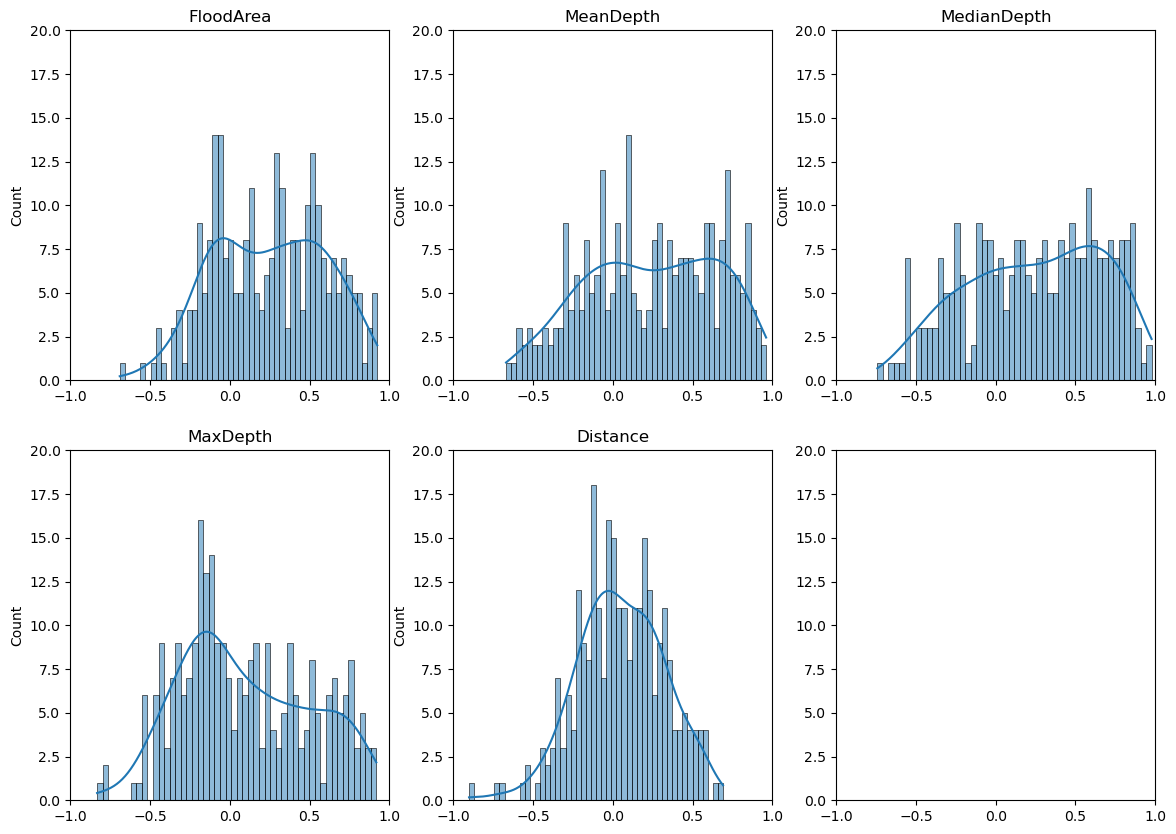

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,3, figsize=(14,10))
sns.histplot(data=pd.Series(corr_Perc), bins=50, ax=ax[0][0], kde=True)
sns.histplot(data=pd.Series(corr_Mean), bins=50, ax=ax[0][1], kde=True)
sns.histplot(data=pd.Series(corr_Median), bins=50, ax=ax[0][2], kde=True)
sns.histplot(data=pd.Series(corr_Max), bins=50, ax=ax[1][0], kde=True)
sns.histplot(data=pd.Series(corr_Dist), bins=50, ax=ax[1][1], kde=True)

[i.set_title(j) for i,j in zip(ax.flatten(), ['FloodArea', 'MeanDepth', 'MedianDepth', 'MaxDepth', 'Distance'])]
[i.set_ylim(0,20) for i in ax.flatten()]
[i.set_xlim(-1,1) for i in ax.flatten()]

### Example Time series plot with VIIRS

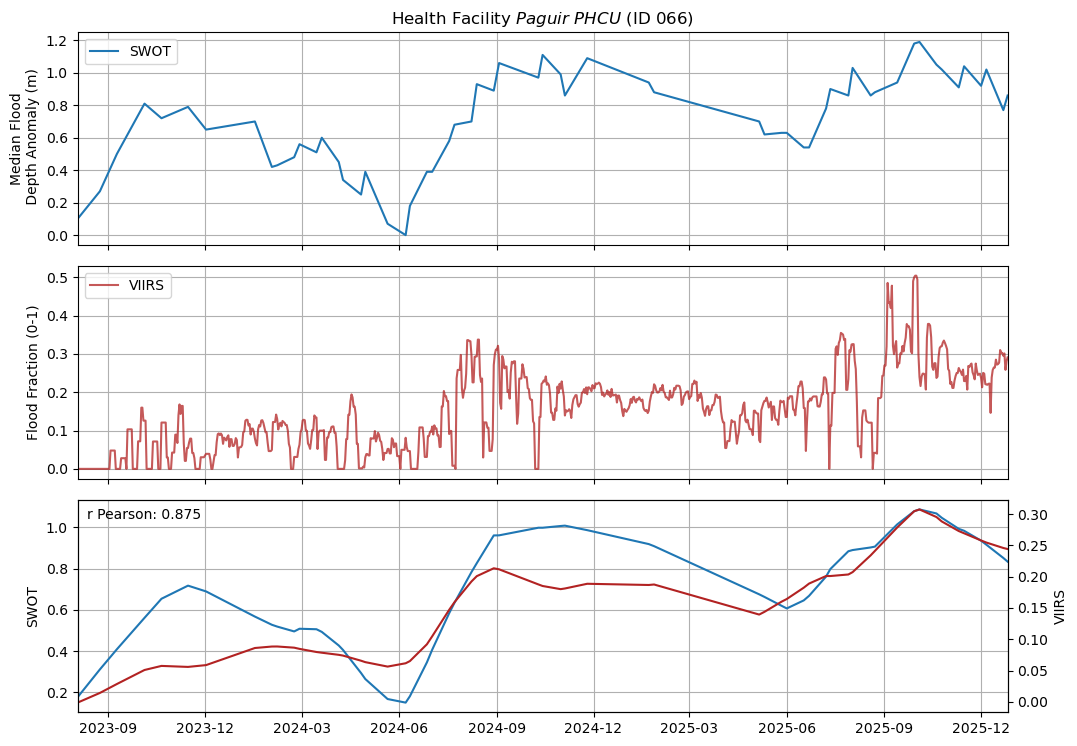

In [ ]:
id='066'
field='Median_anomaly'
plot=True

def corr(_swot, viirs):
    from statsmodels.tsa.seasonal import STL
    from statsmodels.nonparametric.smoothers_lowess import lowess

    viirs_trend = STL(viirs, period=60).fit().trend.rename('VIIRS-trend')  # Good for regular series
    swot_trend_array  = lowess(_swot.values, _swot.index, frac=0.15)       # Good for irregulares
    swot_trend        = pd.Series(swot_trend_array[:,1],
                                index=pd.to_datetime(swot_trend_array[:, 0]),
                                name='SWOT-trend')
    viirs_trend_reindex = viirs_trend.reindex(swot_trend.index, method='nearest')
        
    r = np.corrcoef(viirs_trend_reindex, swot_trend)[0,1]

    return round(r, 3), swot_trend, viirs_trend_reindex

id = id if id is not None else Model.random_id

# SWOT series
_swot = Model.getSerie(id)[field]
_swot.index = _swot.index.normalize()
_swot.index = _swot.index.tz_localize(None)

viirs = swot.VIIRS().getSeries(id)['pct_flooded']
viirs = viirs.loc[_swot.index.min():_swot.index.max()]

r, swot_trend, viirs_trend_reindex = corr(_swot, viirs)

if plot:
    import matplotlib.dates as mdates
    from matplotlib.ticker import NullLocator
    fig, ax = plt.subplots(3,1, figsize=(12,10), sharex=True)

    _swot.plot(ax=ax[0],
               title=f'Health Facility $\\mathit{{Paguir\ PHCU}}$ (ID {id})',
               grid=True, legend=True, label='SWOT')
    ax[0].set_ylabel('Median Flood\n Depth Anomaly (m)')

    viirs.plot(ax=ax[1], color='#b22222ff', grid=True, legend=True, alpha=0.75,
               label='VIIRS')
    ax[1].set_ylabel('Flood Fraction (0-1)')

    swot_trend.plot(ax=ax[2], grid=True, ylabel='SWOT')
    viirs_trend_reindex.plot(ax=ax[2].twinx(), color='#b22222ff', ylabel='VIIRS')
    ax[2].text(0.01,0.91, f"r Pearson: {r}", transform=ax[2].transAxes)
    # ax[2].text(0.93,0.93, f"TRENDS", transform=ax[2].transAxes)

    # Time axis every 2 months, numeric year-month, no redundant ticks
    locator = mdates.MonthLocator(interval=3)
    formatter = mdates.DateFormatter('%Y-%m')
    ax[2].xaxis.set_major_locator(locator)
    ax[2].xaxis.set_major_formatter(formatter)
    ax[2].xaxis.set_minor_locator(NullLocator())
    ax[2].tick_params(axis='x', labelrotation=0)
    for label in ax[2].get_xticklabels():
        label.set_ha('center')

    plt.subplots_adjust(hspace=0.1)
    [i.set_xlim(_swot.index.min(), _swot.index.max()) for i in ax]